In [ ]:
import sys
import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Import local modules
from delta_config import get_config, get_models, ensure_output_dir, BASE_PATH, VERSION
from delta_data_prep import (
    prepare_full_pipeline,
    prepare_delta_data_for_year,
    get_available_target_years
)
from delta_modeling import run_full_loco
from delta_feature_selection import run_all_selections
from delta_visualization import export_year_predictions

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Imports successful")

✓ Imports successful


## 1. Configuration

In [2]:
# Get configuration
config = get_config()

print("Configuration:")
for k, v in config.items():
    if k != 'models':
        print(f"  {k}: {v}")
print(f"  models: {list(config['models'].keys())}")

# Create output directory
output_dir = ensure_output_dir()
print(f"\nOutput directory: {output_dir}")

Configuration:
  target_mode: delta_incidence
  exclude_years: []
  exclude_countries: []
  exclude_features: []
  min_countries_per_year: 5
  nan_threshold: 0.5
  random_state: 42
  output_dir: /home/raspigeon/Documents/GML_RespiratoryDiseases/COPD_incidence/delta_analysis/outputs
  models: ['Ridge', 'XGBoost']

Output directory: /home/raspigeon/Documents/GML_RespiratoryDiseases/COPD_incidence/delta_analysis/outputs


## 2. Data Preparation

Load data, compute delta features for all feature columns.

In [3]:
# Load and prepare base data with deltas
df_base, base_feature_cols, target_years = prepare_full_pipeline(
    BASE_PATH, VERSION, config
)

print(f"\nBase dataset shape: {df_base.shape}")
print(f"Base features: {len(base_feature_cols)}")
print(f"Target years available: {target_years}")

LOADING AND IMPUTING BASE DATA
✓ Loaded 773 rows, 42 columns
  Years: 1990 - 2019
  Countries: 57
✓ Target imputation complete. Remaining NaN in Value: 0
⚠ Dropping 3 columns with >50% NaN:
    - Poverty headcount ratio at national poverty lines (% of population) (82.3% NaN)
    - Prevalence tobacco use (70.5% NaN)
    - Total sales of agricultural pesticides (tonnes) (80.9% NaN)
✓ After ffill/bfill: 569 NaN remaining in features
  Applying IterativeImputer for remaining NaN...
✓ After IterativeImputer: 0 NaN remaining
✓ 32 base features identified
✓ Computed deltas for 32 features + incidence
✓ 27 target years available: [np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2012), np.int64(2013), np.int64(2014), n

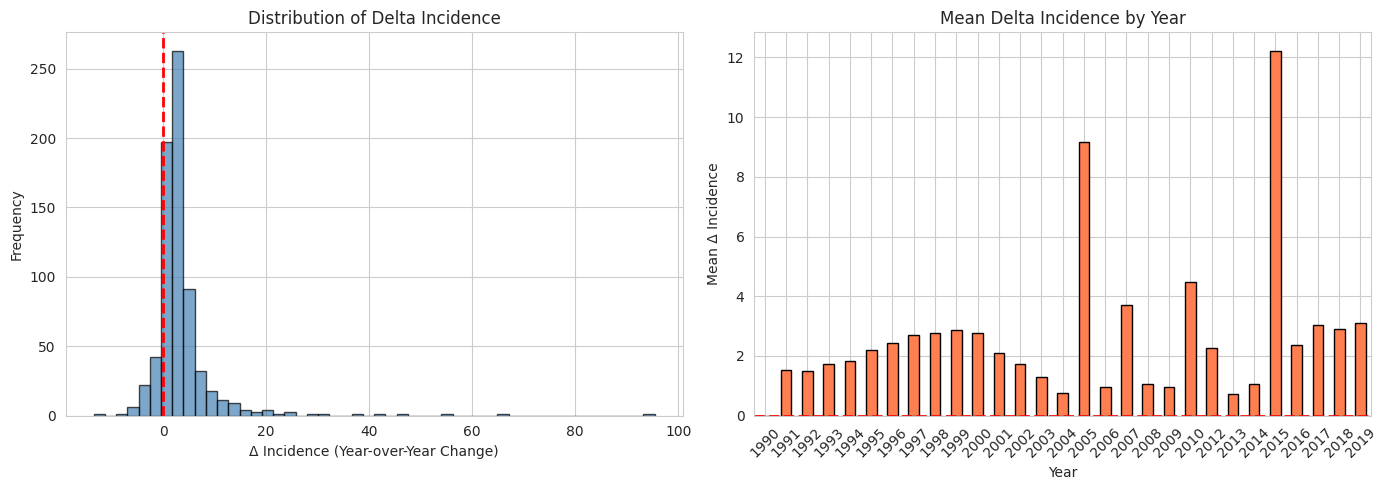

In [4]:
# Show delta_incidence distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of delta_incidence
delta_vals = df_base['delta_incidence'].dropna()
axes[0].hist(delta_vals, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Δ Incidence (Year-over-Year Change)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Delta Incidence')

# Delta by year
df_base.groupby('Year')['delta_incidence'].mean().plot(kind='bar', ax=axes[1], 
                                                        color='coral', edgecolor='black')
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Mean Δ Incidence')
axes[1].set_title('Mean Delta Incidence by Year')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 3. Analysis for Each Target Year

For each target year:
1. Build stacked delta features dataset
2. Run feature selection (4 combinations: Ridge×RMSE, Ridge×Worst, XGBoost×RMSE, XGBoost×Worst)
3. Run full LOCO evaluation
4. Export results

In [5]:
# Storage for all results
all_predictions = []
all_selection_results = {}
year_summaries = []
timing_info = []  # Track timing per year

# Checkpoint: Check which years have already been processed
checkpoint_file = os.path.join(output_dir, 'checkpoint.txt')
completed_years = set()

if os.path.exists(checkpoint_file):
    with open(checkpoint_file, 'r') as f:
        completed_years = set(int(y.strip()) for y in f.readlines() if y.strip())
    print(f"✓ Found checkpoint: {len(completed_years)} years already completed")
    print(f"  Completed years: {sorted(completed_years)}")

# Filter out completed years
remaining_years = [y for y in target_years if y not in completed_years]

print(f"\nProcessing {len(remaining_years)} remaining target years (of {len(target_years)} total)...")
print("=" * 60)

✓ Found checkpoint: 25 years already completed
  Completed years: [1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2012, 2013, 2014, 2015, 2016, 2017]

Processing 2 remaining target years (of 27 total)...


In [6]:
# OPTIONAL: Clear checkpoint to restart from scratch
# Uncomment the lines below to reset and reprocess all years

# checkpoint_file = os.path.join(output_dir, 'checkpoint.txt')
# if os.path.exists(checkpoint_file):
#     os.remove(checkpoint_file)
#     print("✓ Checkpoint cleared - will reprocess all years")
# 
# # Also clear all output files if you want a fresh start
# import glob
# for f in glob.glob(os.path.join(output_dir, '*.csv')):
#     os.remove(f)
# for f in glob.glob(os.path.join(output_dir, '*.png')):
#     os.remove(f)
# print("✓ All output files cleared")

In [7]:
# Process each target year with timing and incremental export
total_start_time = time.time()

for idx, target_year in enumerate(remaining_years):
    year_start_time = time.time()
    
    print(f"\n{'#' * 60}")
    print(f"# TARGET YEAR: {target_year} (predicting Δincidence {target_year}→{target_year+1})")
    print(f"# Progress: {idx+1}/{len(remaining_years)} remaining | {len(completed_years)+idx+1}/{len(target_years)} total")
    print(f"{'#' * 60}")
    
    # Build dataset for this target year
    year_df, feature_cols, family_map = prepare_delta_data_for_year(
        df_base, base_feature_cols, target_year, normalize=True
    )
    
    if year_df.empty or len(feature_cols) == 0:
        print(f"  ⚠ Skipping year {target_year}: insufficient data")
        continue
    
    print(f"\n  Dataset: {len(year_df)} countries, {len(feature_cols)} features")
    
    # Run feature selection with incremental export
    fs_start = time.time()
    print("\n  Running feature selection...")
    selection_results = run_all_selections(
        year_df, feature_cols, family_map, config, verbose=True,
        export_dir=output_dir, target_year=target_year  # Incremental export!
    )
    fs_time = time.time() - fs_start
    all_selection_results[target_year] = selection_results
    
    # Run full LOCO with all features (baseline)
    loco_start = time.time()
    print("\n  Running LOCO evaluation (all features)...")
    predictions_df, metrics = run_full_loco(
        year_df, feature_cols, config, verbose=True
    )
    loco_time = time.time() - loco_start
    
    if not predictions_df.empty:
        predictions_df['target_year'] = target_year
        all_predictions.append(predictions_df)
        
        # Summary for this year
        for model_name, m in metrics.items():
            year_summaries.append({
                'target_year': target_year,
                'model': model_name,
                'n_features': len(feature_cols),
                'n_countries': len(year_df),
                'rmse': m['rmse'],
                'worst_case': m['worst_case'],
                'mae': m['mae'],
            })
    
    # Export year predictions immediately
    if not predictions_df.empty:
        export_year_predictions(predictions_df, target_year, output_dir)
    
    # Timing for this year
    year_time = time.time() - year_start_time
    elapsed_total = time.time() - total_start_time
    years_remaining = len(remaining_years) - (idx + 1)
    avg_time_per_year = elapsed_total / (idx + 1)
    estimated_remaining = avg_time_per_year * years_remaining
    
    timing_info.append({
        'target_year': target_year,
        'feature_selection_time_s': fs_time,
        'loco_time_s': loco_time,
        'total_year_time_s': year_time,
    })
    
    # Save timing incrementally
    timing_df_temp = pd.DataFrame(timing_info)
    timing_df_temp.to_csv(os.path.join(output_dir, 'timing_info.csv'), index=False)
    
    # Update checkpoint
    completed_years.add(target_year)
    with open(checkpoint_file, 'w') as f:
        f.write('\n'.join(str(y) for y in sorted(completed_years)))
    
    print(f"\n  ⏱ Timing for year {target_year}:")
    print(f"    Feature Selection: {fs_time:.1f}s")
    print(f"    LOCO Evaluation: {loco_time:.1f}s")
    print(f"    Total: {year_time:.1f}s")
    print(f"\n  📊 Overall Progress:")
    print(f"    Elapsed: {elapsed_total/60:.1f} min")
    print(f"    Estimated remaining: {estimated_remaining/60:.1f} min")
    print(f"    Avg per year: {avg_time_per_year:.1f}s")
    print(f"  ✓ Checkpoint saved ({len(completed_years)} years done)")

total_time = time.time() - total_start_time
print("\n" + "=" * 60)
print(f"Processing complete! Total time: {total_time/60:.1f} min")
print(f"Total years processed: {len(completed_years)}")
print("=" * 60)


############################################################
# TARGET YEAR: 2010 (predicting Δincidence 2010→2011)
# Progress: 1/2 remaining | 26/27 total
############################################################
  Target year 2010: 20 lag years available ([np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010)])
  ⚠ Skipping year 2010: insufficient data

############################################################
# TARGET YEAR: 2018 (predicting Δincidence 2018→2019)
# Progress: 2/2 remaining | 27/27 total
############################################################
  Target year 2018: 27 lag years available ([np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), n

## 4. Completion Summary

All results have been exported to the `outputs/` directory. Use `delta_results_analysis.ipynb` to analyze the results.

In [27]:
# List all exported files
import glob

print("=" * 70)
print("EXPORTED FILES")
print("=" * 70)

csv_files = sorted(glob.glob(os.path.join(output_dir, '*.csv')))
print(f"\nTotal CSV files: {len(csv_files)}")
for f in csv_files[:15]:  # Show first 15
    size = os.path.getsize(f) / 1024
    print(f"  📄 {os.path.basename(f)} ({size:.1f} KB)")
if len(csv_files) > 15:
    print(f"  ... and {len(csv_files) - 15} more files")

print(f"\n📁 Output directory: {output_dir}")
print(f"\n✅ Run 'delta_results_analysis.ipynb' to analyze these results.")

EXPORTED FILES

Total CSV files: 163
  📄 all_predictions.csv (87.1 KB)
  📄 comprehensive_metrics_summary.csv (0.5 KB)
  📄 errors_by_country.csv (12.7 KB)
  📄 errors_by_year_country.csv (82.6 KB)
  📄 feature_selection_summary.csv (1.2 KB)
  📄 fs_history_1991_Ridge_rmse.csv (0.6 KB)
  📄 fs_history_1991_Ridge_worst_case.csv (0.9 KB)
  📄 fs_history_1991_XGBoost_rmse.csv (0.4 KB)
  📄 fs_history_1991_XGBoost_worst_case.csv (0.6 KB)
  📄 fs_history_1992_Ridge_rmse.csv (1.3 KB)
  📄 fs_history_1992_Ridge_worst_case.csv (0.6 KB)
  📄 fs_history_1992_XGBoost_rmse.csv (0.8 KB)
  📄 fs_history_1992_XGBoost_worst_case.csv (0.4 KB)
  📄 fs_history_1993_Ridge_rmse.csv (2.2 KB)
  📄 fs_history_1993_Ridge_worst_case.csv (0.8 KB)
  ... and 148 more files

📁 Output directory: /home/raspigeon/Documents/GML_RespiratoryDiseases/COPD_incidence/delta_analysis/outputs

✅ Run 'delta_results_analysis.ipynb' to analyze these results.
